In [1]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel



if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

# Nastav working directory na kořen projektu
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f"✓ Working directory: {os.getcwd()}")
# PFNs — musí být naklonováno (viz setup.sh)
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print("✓ PFNs načteny")

✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG
✓ PFNs načteny


In [2]:
# =============================================
# LOAD HELPER 
# =============================================

def load_pfn_model(checkpoint_path, device='cpu'):
    """
    Načte PFN model z checkpointu. Podporuje tři formáty:

    1. Nový formát (MainConfig dict, 'priors' key):
       - Uloženo přes epoch loop v PFN_TRAIN_SETUP.ipynb nebo pfn_train*.py
       - Config obsahuje celou architekturu → nlayers, emsize atd. se čtou automaticky

    2. Starý formát ('hps' key):
       - Uloženo přes train_gp_pfn()
       - Config obsahuje jen HP, architektura se musí rekonstruovat
       - nlayers se pokusí přečíst z config; pokud chybí, vyhodí chybu

    Vrací: (model, hps, epoch)
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Model nenalezen: {checkpoint_path}\n")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config_data = checkpoint.get('config', {})

    # --- Formát 1: MainConfig dict (nový) ---
    if isinstance(config_data, dict) and 'priors' in config_data:
        saved_config = MainConfig.from_dict(config_data)
        model = saved_config.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        hps = saved_config.priors[0].prior_kwargs.get('hyperparameters', {})
        epoch = checkpoint.get('epoch', '?')

    # --- Formát 2: starý formát ('hps' key) ---
    elif isinstance(config_data, dict) and 'hps' in config_data:
        hps = config_data['hps']
        epoch = config_data.get('epochs', checkpoint.get('epoch', '?'))
        criterion = checkpoint['criterion']

        nlayers = config_data.get('nlayers')
        if nlayers is None:
            # Odvoď nlayers ze state_dict — spočítej nejvyšší index vrstvy
            layer_indices = [
                int(k.split('.')[2])
                for k in checkpoint['model_state_dict']
                if k.startswith('transformer_layers.layers.')
            ]
            nlayers = max(layer_indices) + 1 if layer_indices else 6

        emsize  = config_data.get('emsize',  512)
        nhead   = config_data.get('nhead',   8)
        nhid    = config_data.get('nhid',    1024)

        cfg = MainConfig(
            priors=[AdhocPriorConfig(
                get_batch_methods=[get_batch_for_gp],
                prior_kwargs={'num_features': 1, 'hyperparameters': hps}
            )],
            optimizer=OptimizerConfig('adamw', lr=0.0003),
            model=TransformerConfig(
                criterion=BarDistributionConfig(
                    full_support=True,
                    borders=criterion.borders.tolist()
                ),
                emsize=emsize, nhead=nhead, nhid=nhid, nlayers=nlayers,
                features_per_group=1,
                attention_between_features=False,
                encoder=EncoderConfig(
                    constant_normalization_mean=0.5,
                    constant_normalization_std=math.sqrt(1/12)
                )
            ),
            batch_shape_sampler=BatchShapeSamplerConfig(
                batch_size=64, max_seq_len=50,
                min_num_features=1, max_num_features=1
            ),
            epochs=1, warmup_epochs=0,
            steps_per_epoch=1, num_workers=0,
        )
        model = cfg.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        model.criterion = criterion

    else:
        raise ValueError(f"Neznámý formát checkpointu. Klíče config: {list(config_data.keys())}")

    model.to(device)
    model.eval()
    print(f"✓ Model načten: {os.path.basename(checkpoint_path)}")
    print(f"  Epocha: {epoch}, nlayers: {nlayers if 'nlayers' in dir() else '(z MainConfig)'}")
    print(f"  Parametrů: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
    return model, hps, epoch

print("✓ load_pfn_model připraven")

✓ load_pfn_model připraven


In [3]:
# =============================================
# NAČTENÍ MODELŮ
# =============================================

# DŮLEŽITÉ: get_batch_for_gp_random_hps musí být definována PŘED torch.load
def get_batch_for_gp_random_hps(batch_size, seq_len, num_features, device="cpu", hyperparameters=None, **kwargs):
    random_hps = {
        "lengthscale": 0.3,
        "outputscale": 0.1,
        "noise":       1.0,
    }
    return get_batch_for_gp(batch_size, seq_len, num_features, device=device, hyperparameters=random_hps, **kwargs)


def load_for_inference(checkpoint_path, device='cpu'):
    """
    Načte libovolný PFN checkpoint pro inferenci.
    Automaticky detekuje nlayers z checkpointu — funguje pro 1L, 2L, 4L, 6L, ...
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config = checkpoint["config"]

    if "num_features" in config:
        # Starý formát
        num_features     = config["num_features"]
        max_dataset_size = config["max_dataset_size"]
        criterion        = checkpoint["criterion"]
        borders          = criterion.borders.tolist()
        nlayers          = config.get("nlayers", 6)
        get_batch_fn     = get_batch_for_gp
        prior_kwargs     = {"num_features": num_features, "hyperparameters": config.get("hps", {})}
    else:
        # Nový formát (MainConfig)
        num_features     = config["priors"][0]["prior_kwargs"]["num_features"]
        max_dataset_size = config["batch_shape_sampler"]["max_seq_len"]
        borders          = config["model"]["criterion"]["borders"]
        nlayers          = config["model"].get("nlayers", 6)
        get_batch_fn     = get_batch_for_gp_random_hps
        prior_kwargs     = {"num_features": num_features, "hyperparameters": {}}
        criterion        = None

    model_config = MainConfig(
        priors=[AdhocPriorConfig(
            get_batch_methods=[get_batch_fn],
            prior_kwargs=prior_kwargs
        )],
        optimizer=OptimizerConfig("adamw", lr=0.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            emsize=512, nhead=8, nhid=1024, nlayers=nlayers,
            features_per_group=1,
            attention_between_features=False,
            encoder=EncoderConfig(
                constant_normalization_mean=0.5,
                constant_normalization_std=math.sqrt(1/12)
            )
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(
            batch_size=2, max_seq_len=max_dataset_size,
            min_num_features=num_features, max_num_features=num_features
        ),
        epochs=1, steps_per_epoch=1, num_workers=0,
    )

    dummy_result = train(model_config, device=device, reusable_config=False)
    model = dummy_result["model"]
    model.load_state_dict(checkpoint["model_state_dict"])
    if criterion is not None:
        model.criterion = criterion
    model.to(device)
    model.eval()

    epoch = checkpoint.get("epoch", "?")
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  ✓ {os.path.basename(checkpoint_path)}: nlayers={nlayers}, epoch={epoch}, {n_params:.2f}M params")
    return model, epoch


# =============================================
# KONFIGURACE MODELŮ — uprav cesty dle potřeby
# =============================================
MODEL_PATHS = {
    "1-layer": os.path.join("models", "pfn_rand_hps_1layer.pth"),
    "2-layer": os.path.join("models", "pfn_rand_hps_2layer.pth"),
    "4-layer": os.path.join("models", "pfn_rand_hps_4layer.pth"),
    "6-layer": os.path.join("models", "pfn_rand_hps_6layer.pth"),
    "8-layer": os.path.join("models", "pfn_rand_hps_8layer.pth"),
}

print("Načítám modely...")
MODELS = {}
for name, path in MODEL_PATHS.items():
    if os.path.exists(path):
        MODELS[name], _ = load_for_inference(path, device)
    else:
        print(f"  ⚠ Nenalezeno: {path}")

# Zpětná kompatibilita — loaded_model = první dostupný model
loaded_model = next(iter(MODELS.values())) if MODELS else None

# =============================================
# GLOBÁLNÍ NASTAVENÍ
# =============================================
hps = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3}

def reset_seed():
    import random
    s = random.randint(0, 2**32 - 1)
    torch.manual_seed(s)
    np.random.seed(s % (2**31))
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def get_batch_cpu(batch_size, seq_len, num_features, hyperparameters, device):
    batch = get_batch_for_gp(batch_size, seq_len, num_features,
                              device="cpu", hyperparameters=hyperparameters)
    from pfns.priors.prior import Batch
    return Batch(x=batch.x.to(device), y=batch.y.to(device), target_y=batch.target_y.to(device))

reset_seed()
print(f"\n✓ Načteno {len(MODELS)} modelů: {list(MODELS.keys())}")

Načítám modely...


init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=100, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_samp

Checkpoint file None not found or load/save paths are identical and file doesn't exist. Starting from scratch.


/Users/ruslanguliev/VU_RG/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.66s | mean loss  1.49 | lr 0.0 | data time  0.07 step time  0.58 forward time  0.31 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_1layer.pth: nlayers=1, epoch=100, 3.65M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.21s | mean loss  1.38 | lr 0.0 | data time  0.00 step time  0.19 forward time  0.08 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_2layer.pth: nlayers=2, epoch=300, 5.75M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.12s | mean loss  1.31 | lr 0.0 | data time  0.00 step time  0.10 forward time  0.03 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_4layer.pth: nlayers=4, epoch=300, 9.94M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size, seq_len, num_features, device='mps', hyperparameters=None, equidistant_x=False, fix_x=None, **kwargs)
), num_features=1, hyperparameters={'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_singl

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.21s | mean loss  1.58 | lr 0.0 | data time  0.00 step time  0.19 forward time  0.07 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_6layer.pth: nlayers=6, epoch=?, 14.14M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_t

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.14s | mean loss  1.43 | lr 0.0 | data time  0.00 step time  0.11 forward time  0.04 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_8layer.pth: nlayers=8, epoch=300, 18.33M params

✓ Načteno 5 modelů: ['1-layer', '2-layer', '4-layer', '6-layer', '8-layer']


In [4]:
print(f"nlayers: {loaded_model.transformer_layers.num_layers}")
print(f"Layers: {len(loaded_model.transformer_layers.layers)}")
print()
for i, layer in enumerate(loaded_model.transformer_layers.layers):
    print(f"=== Layer {i} ===")
    for name, module in layer.named_children():
        print(f"  {name}: {type(module).__name__}")


for name, module in loaded_model.named_modules():
    if 'self_attn' in name:
        print(name, type(module).__name__)

nlayers: 1
Layers: 1

=== Layer 0 ===
  self_attn_between_items: MultiHeadAttention
  mlp: MLP
  layer_norms: ModuleList
transformer_layers.layers.0.self_attn_between_items MultiHeadAttention


# Experiment 1 (sloučeno s Experimentem 3)

EXPERIMENT: Label Mixing vs. Kernel Computation per Layer
Modely: ['1-layer', '2-layer', '4-layer', '6-layer', '8-layer']

Parametry:
  Instancí:          200
  Trénovacích bodů:  40
  Testovacích bodů:  20
  Lengthscale (NW):  0.5
  Device:            mps

Generuji sdílená data...
  Generuji 50/200
  Generuji 100/200


  Generuji 150/200


  Generuji 200/200
✓ 200 instancí vygenerováno

→ Model: 1-layer


  Instance 50/200


  Instance 100/200


...

  Instance 50/200


  Instance 100/200


  Instance 150/200


  Instance 200/200



=== Srovnávací výsledky ===


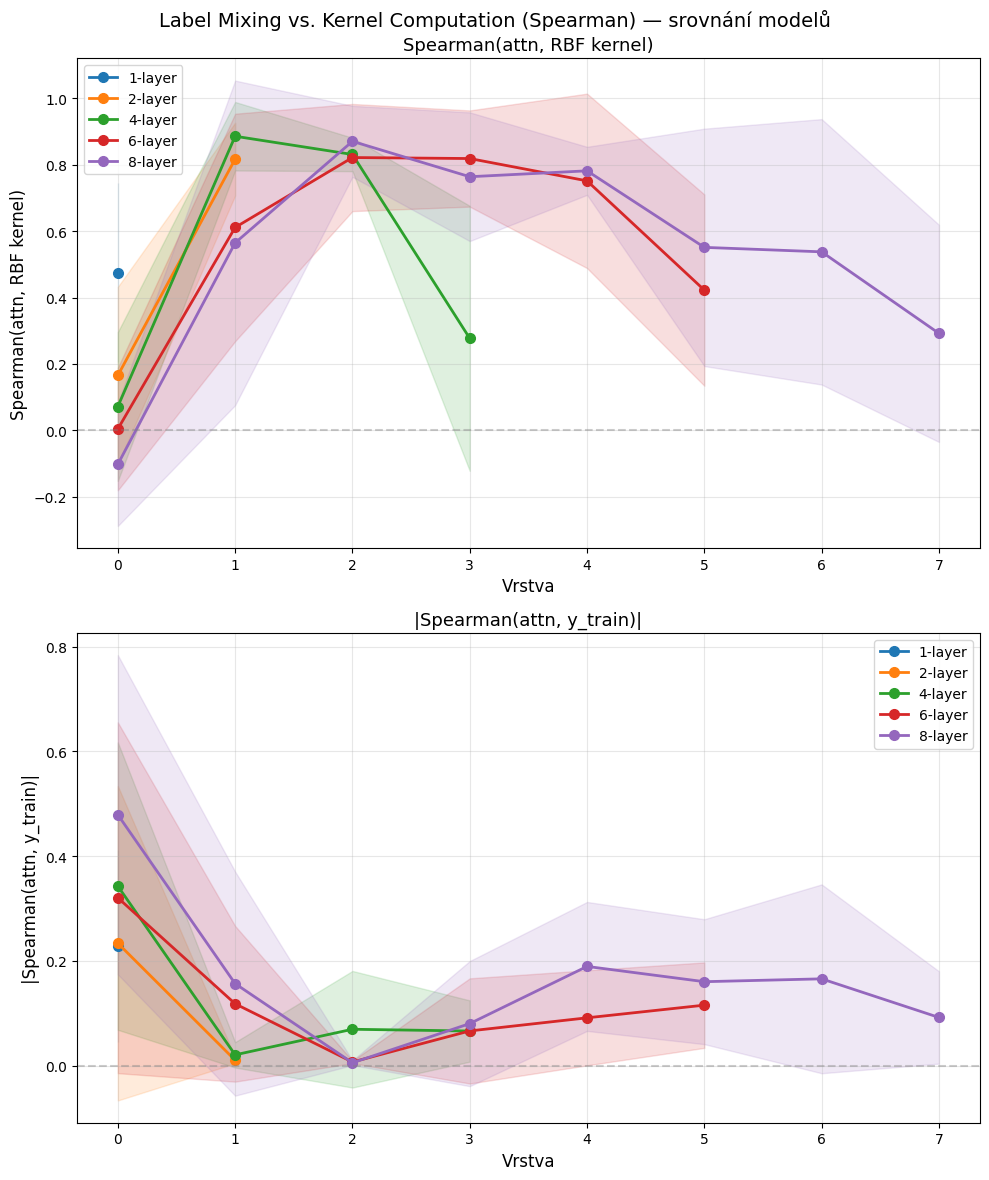


=== Průměrná corr(kernel) (řádky = vrstvy, sloupce = modely) ===
  Vrstva     1-layer     2-layer     4-layer     6-layer     8-layer
--------------------------------------------------------------------
       0      0.4754      0.1655      0.0719      0.0041     -0.1022
       1           —      0.8170      0.8859      0.6112      0.5648
       2           —           —      0.8310      0.8218      0.8706
       3           —           —      0.2772      0.8188      0.7640
       4           —           —           —      0.7515      0.7818
       5           —           —           —      0.4225      0.5512
       6           —           —           —           —      0.5378
       7           —           —           —           —      0.2922

--- 1-layer ---


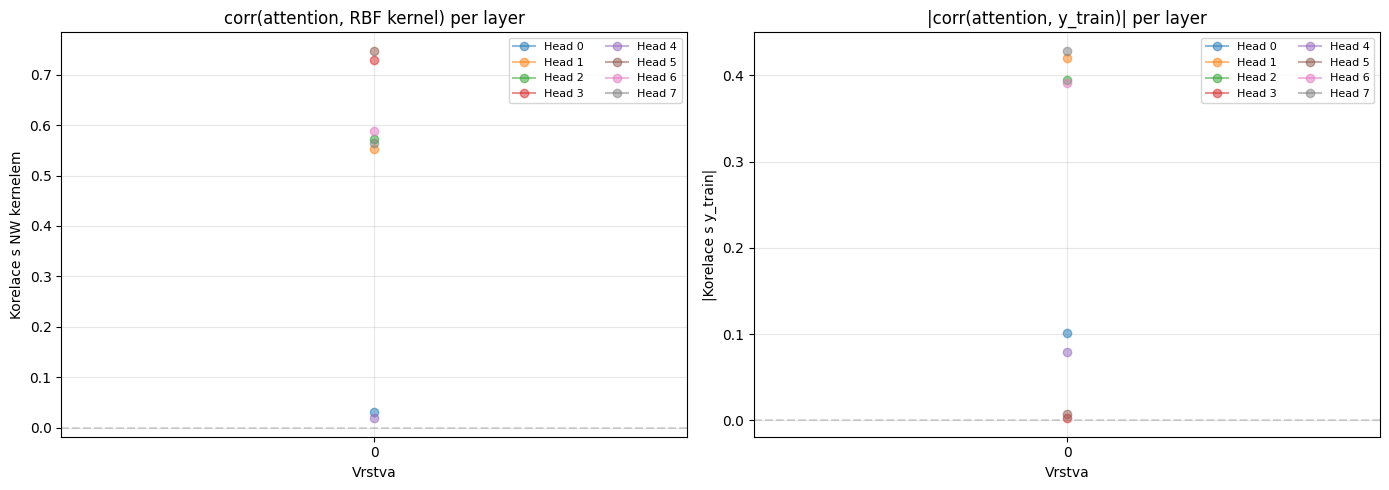

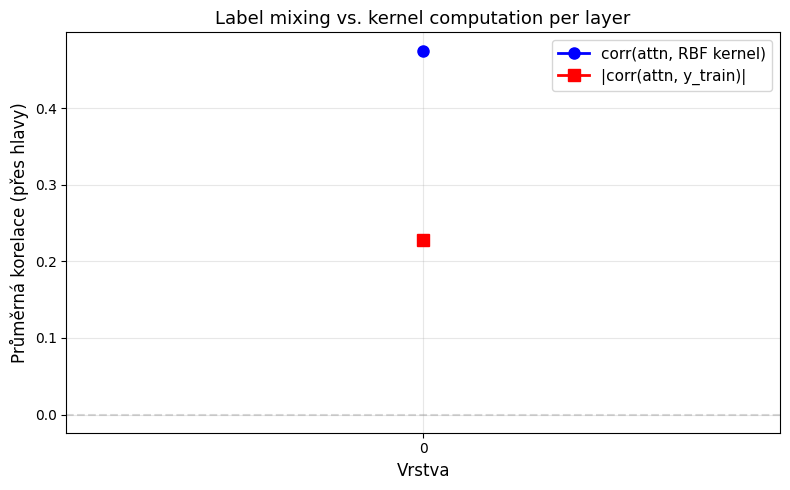


=== Průměrná korelace (přes hlavy) ===
  Vrstva |  corr(kernel) |  |corr(label)|
------------------------------------------
       0 |        0.4754 |         0.2280

--- 2-layer ---


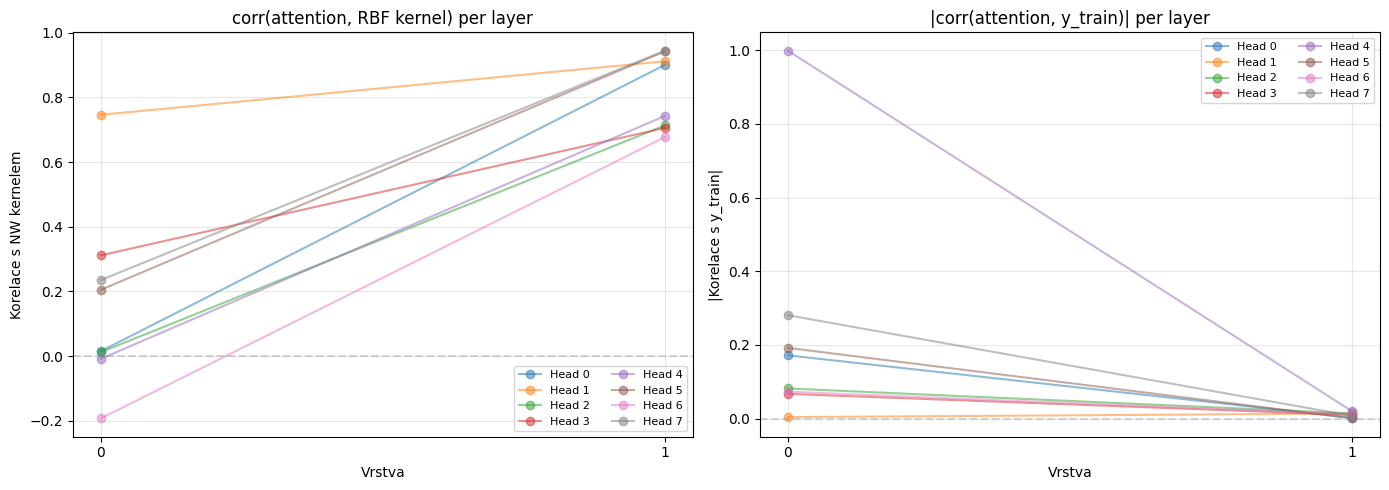

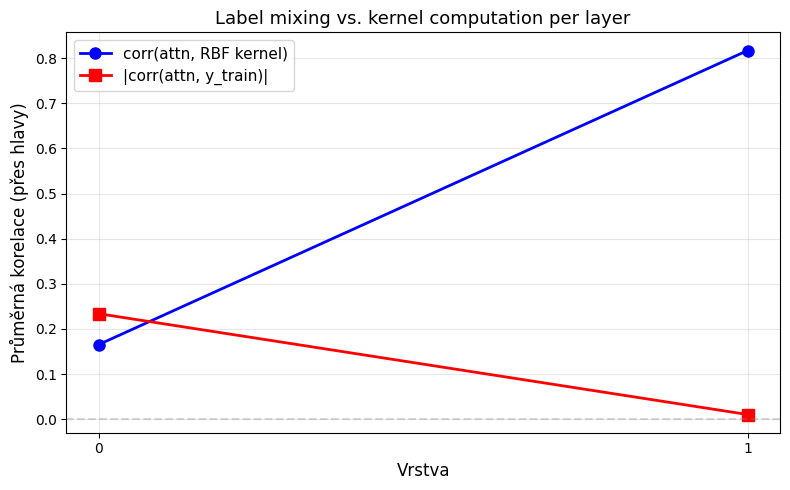


=== Průměrná korelace (přes hlavy) ===
  Vrstva |  corr(kernel) |  |corr(label)|
------------------------------------------
       0 |        0.1655 |         0.2337
       1 |        0.8170 |         0.0103

--- 4-layer ---


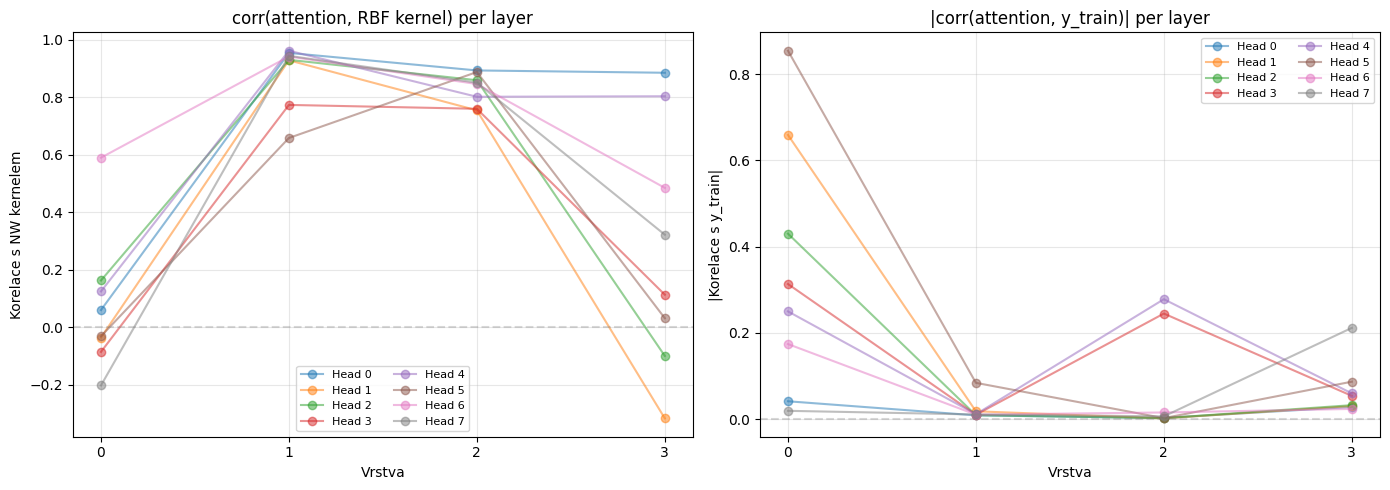

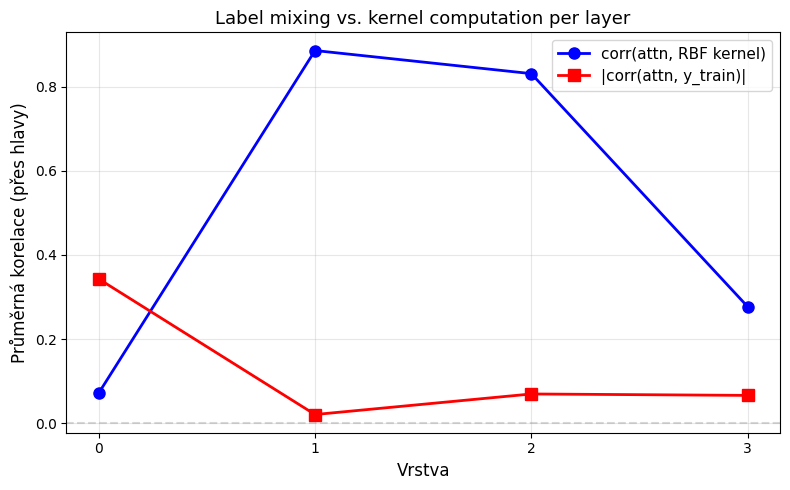


=== Průměrná korelace (přes hlavy) ===
  Vrstva |  corr(kernel) |  |corr(label)|
------------------------------------------
       0 |        0.0719 |         0.3428
       1 |        0.8859 |         0.0206
       2 |        0.8310 |         0.0695
       3 |        0.2772 |         0.0661

--- 6-layer ---


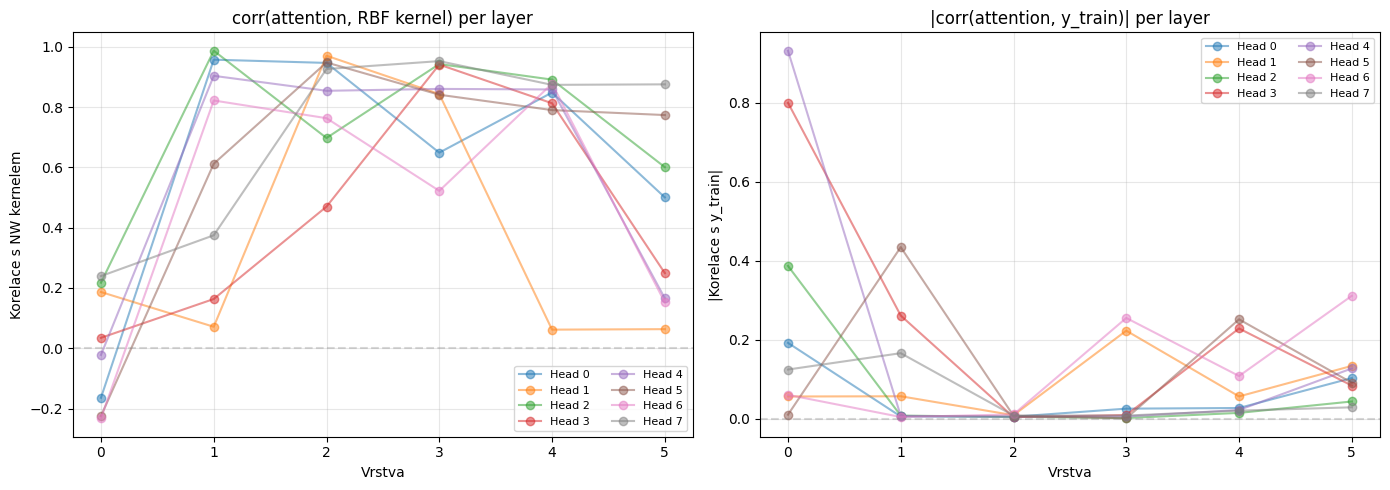

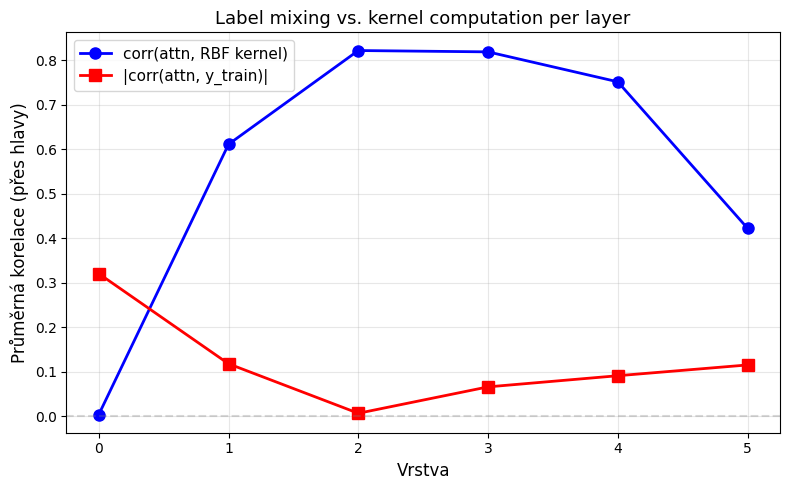


=== Průměrná korelace (přes hlavy) ===
  Vrstva |  corr(kernel) |  |corr(label)|
------------------------------------------
       0 |        0.0041 |         0.3205
       1 |        0.6112 |         0.1181
       2 |        0.8218 |         0.0069
       3 |        0.8188 |         0.0663
       4 |        0.7515 |         0.0913
       5 |        0.4225 |         0.1155

--- 8-layer ---


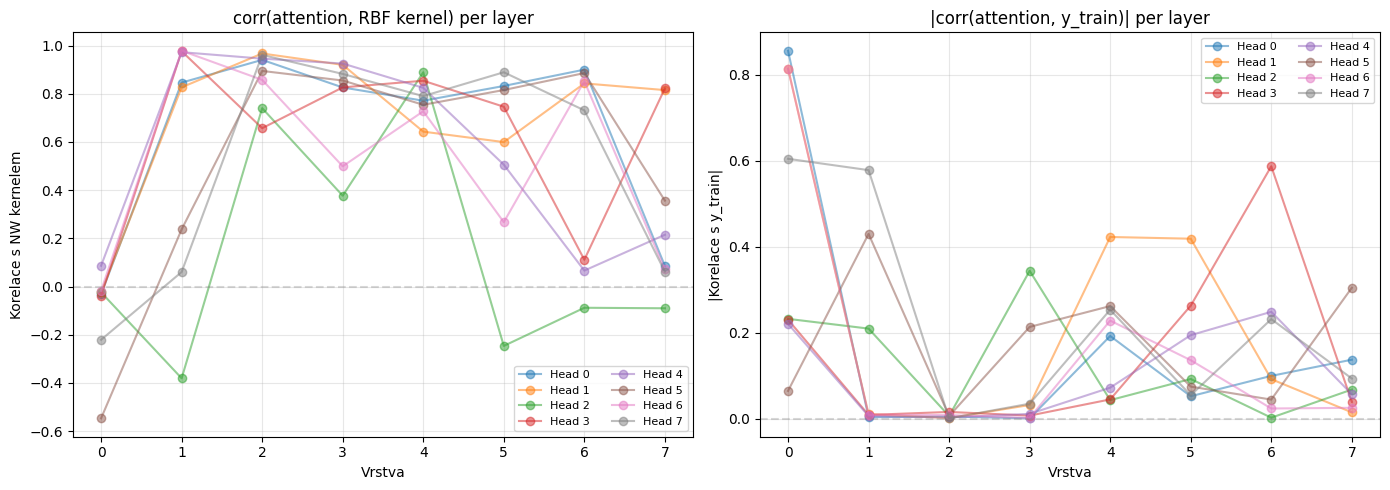

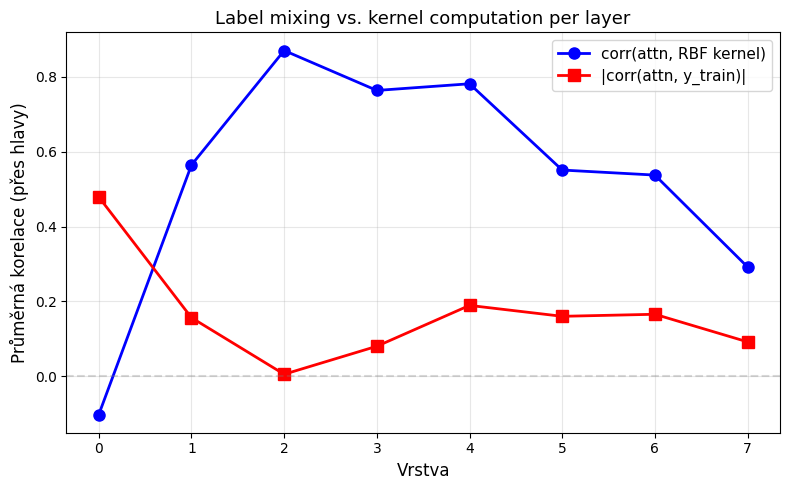


=== Průměrná korelace (přes hlavy) ===
  Vrstva |  corr(kernel) |  |corr(label)|
------------------------------------------
       0 |       -0.1022 |         0.4791
       1 |        0.5648 |         0.1566
       2 |        0.8706 |         0.0054
       3 |        0.7640 |         0.0803
       4 |        0.7818 |         0.1894
       5 |        0.5512 |         0.1603
       6 |        0.5378 |         0.1658
       7 |        0.2922 |         0.0920

=== MSE Dekompozice ===
  Generuji MSE datasety...


    n=5: 200 instanci


    n=10: 200 instanci


    n=20: 200 instanci


    n=40: 200 instanci


...

    n=  10: MSE = 0.000737


    n=  20: MSE = 0.000235


    n=  40: MSE = 0.000096


    n=  80: MSE = 0.000060


    n= 120: MSE = 0.000038


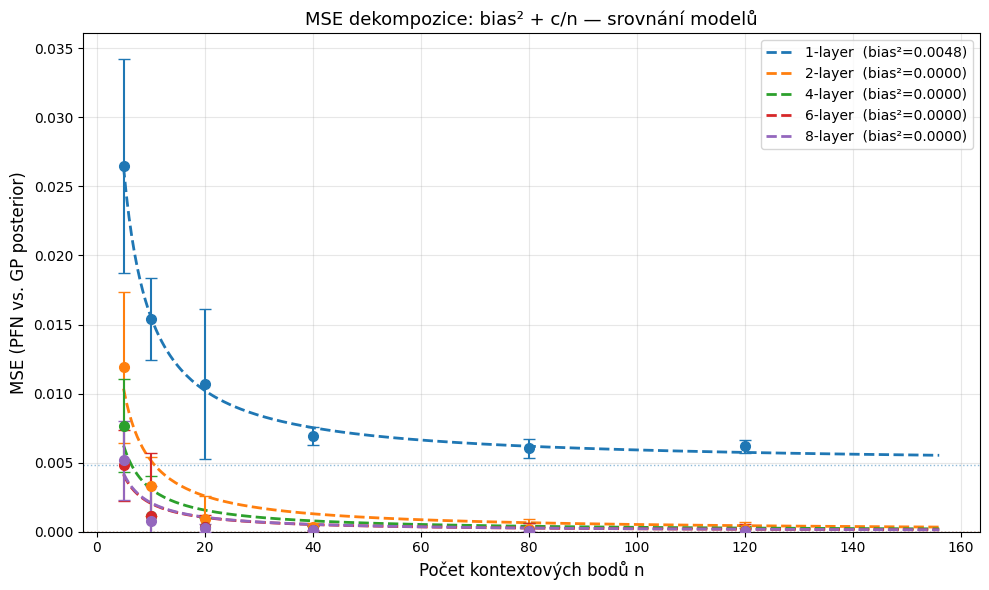


=== Výsledky MSE dekompozice ===
Model             bias²        c  Interpretace
-------------------------------------------------------
1-layer         0.00484    0.108  bias² je signifikantní
2-layer         0.00000    0.052  bias² je nesignif.
4-layer         0.00000    0.031  bias² je nesignif.
6-layer         0.00000    0.021  bias² je nesignif.
8-layer         0.00000    0.021  bias² je nesignif.

=== Iso-Weight Scatter (vrstva 0) — pouze 1-layer a 2-layer ===

--- 1-layer ---


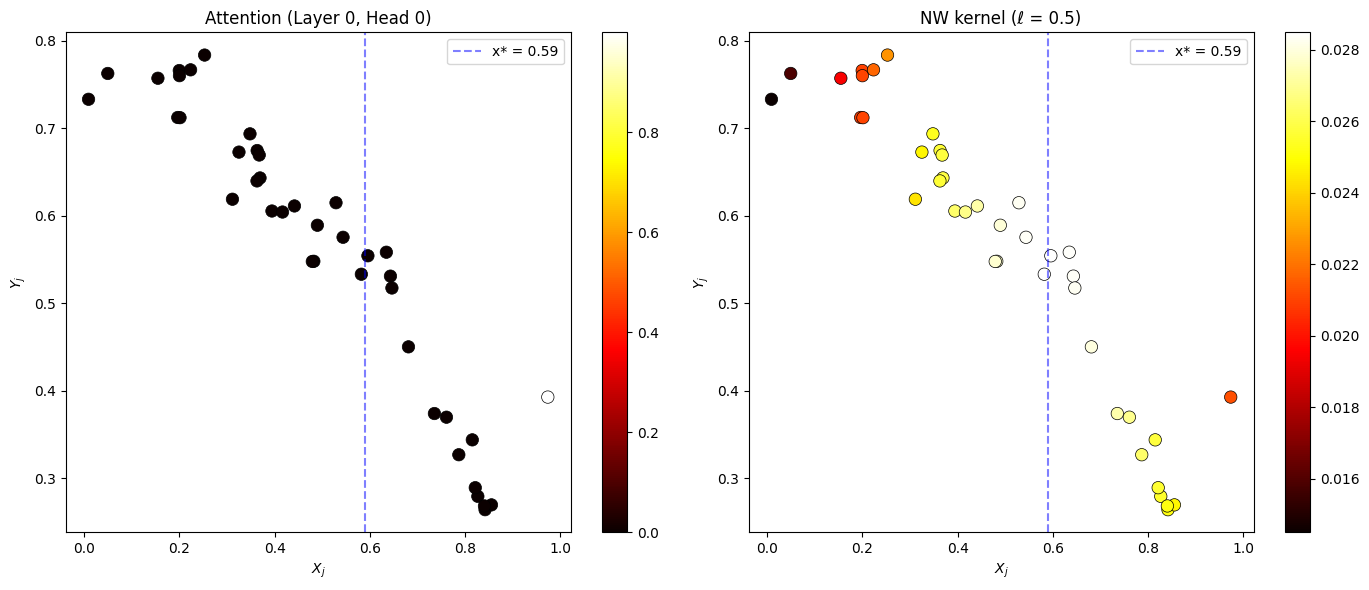

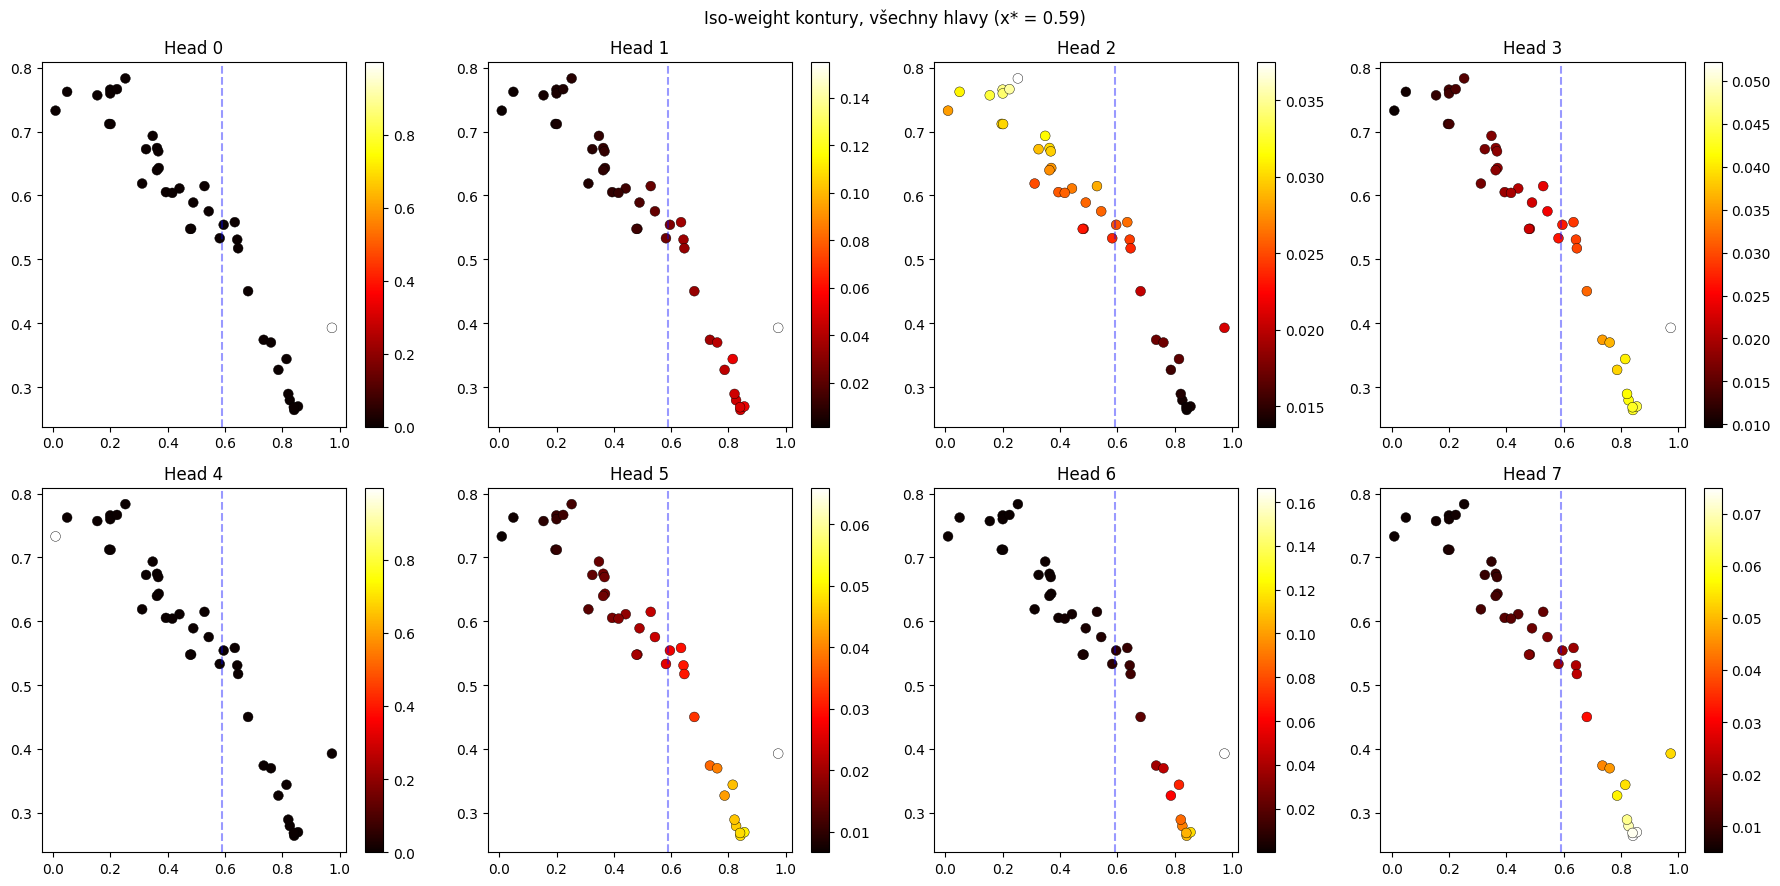


--- 2-layer ---


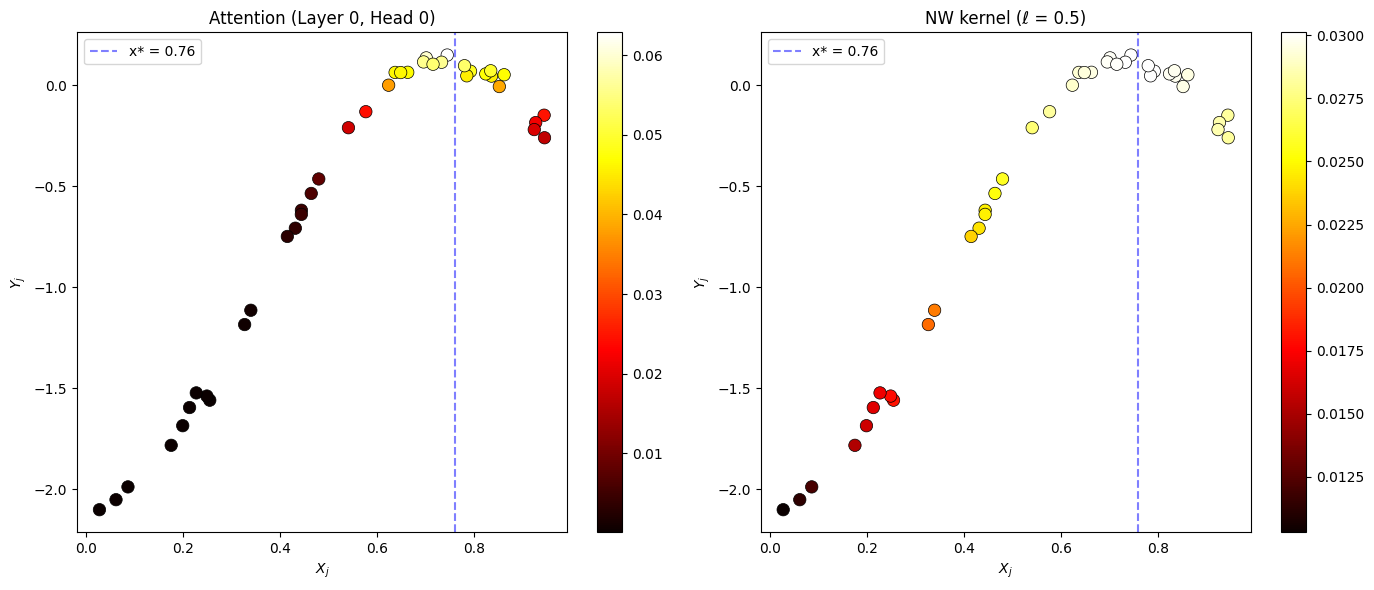

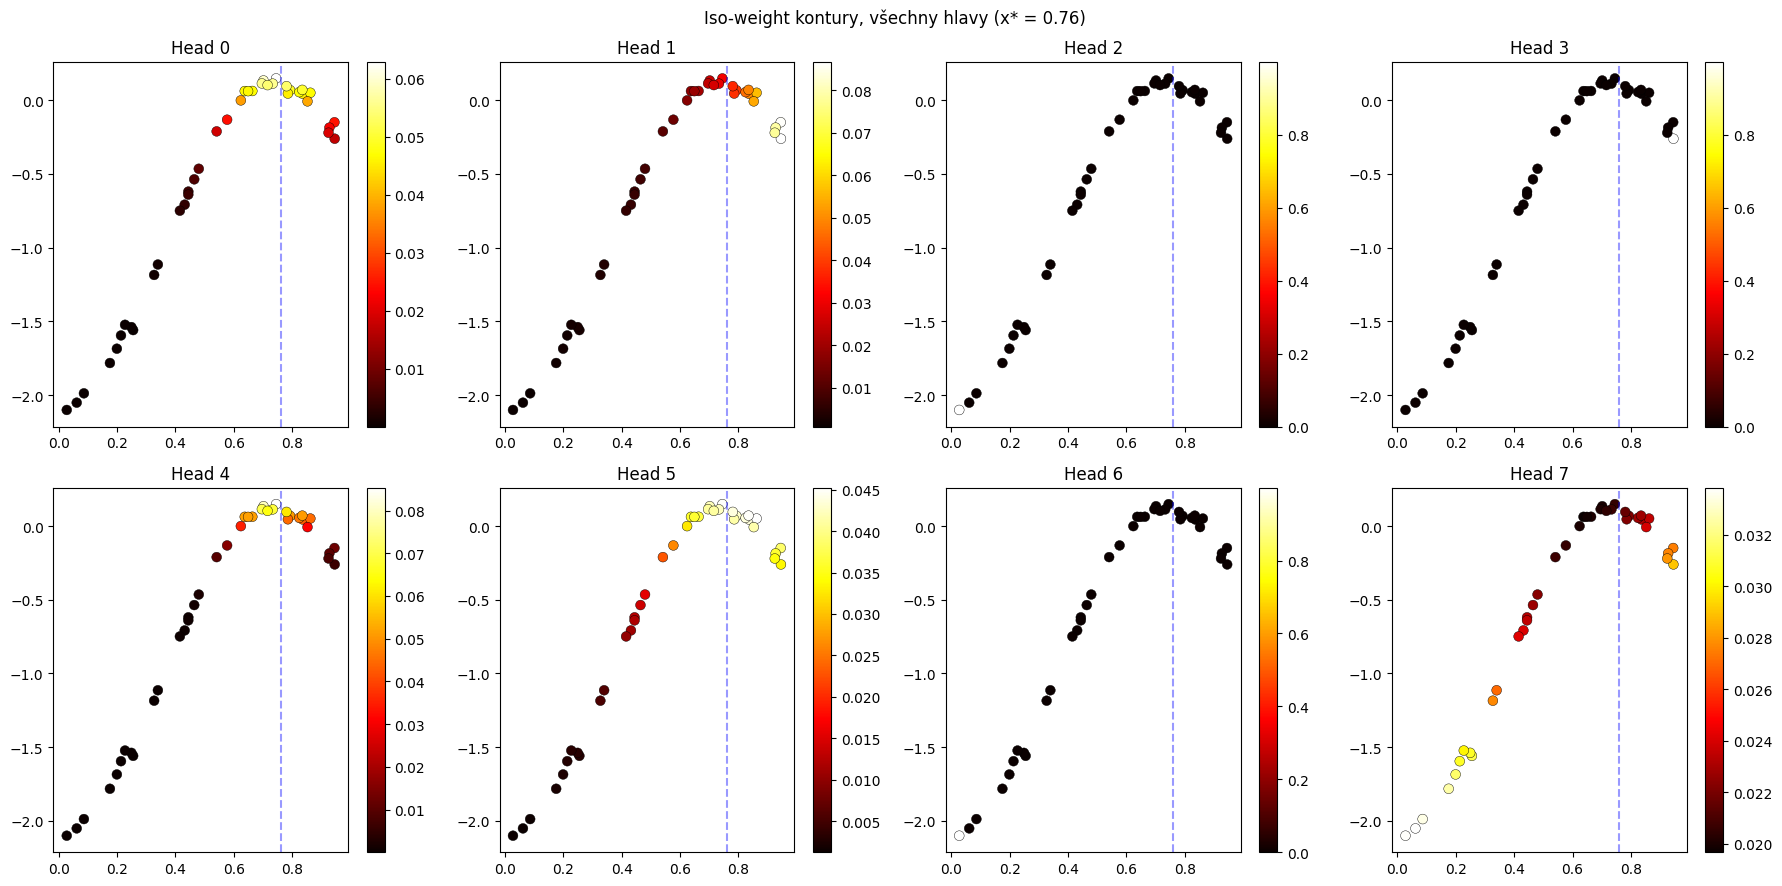


=== Interpretace ===
Pokud corr(kernel) roste s hloubkou a |corr(label)| klesá:
  → Rané vrstvy mísí X a Y, pozdější se specializují na kernel
Pokud oba jsou ploché:
  → Žádná specializace, mísení je uniformní přes vrstvy
Srovnání modelů:
  → 1-layer: corr(kernel) nízká (Nagler Thm 5.4 — bias nemůže vymizet)
  → S počtem vrstev by měla narůstat specializace rané → pozdní vrstva


In [5]:
# =============================================
# EXPERIMENT: Label Mixing vs. Kernel Computation per Layer (Q1)
# =============================================
# Otázka: Mísí se X_j a Y_j v attention score rovnoměrně přes 
# všechny vrstvy, nebo se rané vrstvy specializují na kernel-like 
# feature comparison a pozdější na label propagation?
#
# Metrika: Pro každou vrstvu a hlavu spočítáme:
#   - corr(attention_weights, NW_kernel_weights)  ... korelace s RBF kernelem
#   - corr(attention_weights, y_train)            ... korelace s labely
#
# Pokud se vrstvy specializují:
#   - corr_kernel by měla růst s hloubkou (pozdější vrstvy → více kernel-like)
#   - corr_label by měla klesat s hloubkou
#
# PŘEDPOKLAD: Model je načtený jako `loaded_model`, device je nastavený,
#             funkce get_batch_for_gp je dostupná, hps jsou definované.
# =============================================


# =============================================
# KROK 1: Funkce pro extrakci attention vah
# =============================================
# Používáme hooky na vstupy do self_attn_between_items,
# pak manuálně počítáme Q, K a attention váhy.
# Důvod: PFNs MultiHeadAttention nevrací attention váhy.

from scipy.stats import spearmanr


def extract_attention_weights(model, train_x, train_y, test_x, n_context):
    """
    Extrahuje attention váhy ze všech vrstev.
    
    Args:
        model: načtený PFN model
        train_x: (n_train, 1) trénovací souřadnice
        train_y: (n_train,) nebo (n_train, 1) trénovací hodnoty
        test_x: (n_test, 1) testovací souřadnice
        n_context: počet trénovacích bodů (= single_eval_pos)
    
    Returns:
        list of tensors, jeden per vrstva, 
        shape (1, 1, n_heads, seq_len, seq_len)
    """
    model.eval()
    layer_inputs = []
    
    def input_hook(module, inputs, output):
        layer_inputs.append(inputs[0].detach().cpu())
    
    # Najdi attention moduly a přidej hooky
    hooks = []
    attn_modules = []
    for name, module in model.named_modules():
        if 'self_attn_between_items' in name and 'self_attn_between_items.' not in name:
            hooks.append(module.register_forward_hook(input_hook))
            attn_modules.append(module)
    
    # Forward pass — DŮLEŽITÉ: test_x musí obsahovat CELOU sekvenci (train+test)
    # a train_x musí být jen trénovací část
    full_x = torch.cat([train_x, test_x], dim=0)  # (n_train + n_test, 1)
    
    with torch.no_grad():
        _ = model(
            train_x.unsqueeze(0),   # (1, n_train, 1)
            train_y.unsqueeze(0),   # (1, n_train) nebo (1, n_train, 1)
            full_x.unsqueeze(0)[:, n_context:]  # (1, n_test, 1) — jen testovací část jako test_x
        )
    
    for hook in hooks:
        hook.remove()
    
    # Manuální výpočet attention vah z hooků
    all_attention_weights = []
    for layer_idx, module in enumerate(attn_modules):
        if layer_idx >= len(layer_inputs):
            break
        
        x = layer_inputs[layer_idx]
        w_qkv = module.w_qkv.cpu()
        
        batch, features, seq_len, embed_dim = x.shape
        n_heads = w_qkv.shape[1]
        head_dim = w_qkv.shape[2]
        
        x_flat = x.reshape(-1, embed_dim)
        
        W_q = w_qkv[0]  # (heads, head_dim, embed)
        W_k = w_qkv[1]  # (heads, head_dim, embed)
        
        W_q_t = W_q.permute(2, 0, 1)  # (embed, heads, head_dim)
        W_k_t = W_k.permute(2, 0, 1)
        
        Q = torch.matmul(x_flat, W_q_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        K = torch.matmul(x_flat, W_k_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        
        Q = Q.reshape(batch, features, seq_len, n_heads, head_dim)
        K = K.reshape(batch, features, seq_len, n_heads, head_dim)
        
        Q = Q.permute(0, 1, 3, 2, 4)  # (batch, features, heads, seq, head_dim)
        K = K.permute(0, 1, 3, 2, 4)
        
        # DŮLEŽITÉ: K source je jen trénovací body (single_eval_pos)
        # Tohle je implementace toho, že model dává K,V jen z tréninku
        K_train = K[:, :, :, :n_context, :]
        
        scores = torch.matmul(Q, K_train.transpose(-2, -1)) / (head_dim ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)
        
        all_attention_weights.append(attn_weights)
    
    return all_attention_weights


# =============================================
# KROK 2: Funkce pro NW kernel váhy
# =============================================

def compute_nw_weights(x_test_val, x_train_np, lengthscale):
    """
    Spočítá Nadaraya-Watson váhy pro jeden testovací bod.
    
    Args:
        x_test_val: skalár, souřadnice testovacího bodu
        x_train_np: (n_train,) souřadnice trénovacích bodů
        lengthscale: délková škála RBF kernelu
    
    Returns:
        (n_train,) normalizované NW váhy
    """
    dists_sq = (x_test_val - x_train_np) ** 2
    kernel_vals = np.exp(-dists_sq / (2 * lengthscale ** 2))
    return kernel_vals / kernel_vals.sum()


# =============================================
# KROK 3: Hlavní experiment
# =============================================

def run_label_mixing_experiment(model, datasets, n_context, n_test,
                                 lengthscale=0.3, device='cpu'):
    """
    Pro každou vrstvu a hlavu spočítá průměrnou korelaci
    attention vah s NW kernelem a s y-hodnotami.

    Args:
        model:       načtený PFN model
        datasets:    list of Batch (vygenerovaný přes generate_datasets)
        n_context:   počet trénovacích bodů
        n_test:      počet testovacích bodů
        lengthscale: délková škála pro NW srovnání
        device:      'cpu', 'cuda', nebo 'mps'

    Returns:
        corr_kernel: (n_layers, n_heads) průměrná korelace s RBF kernelem
        corr_label:  (n_layers, n_heads) průměrná korelace s y_train
    """
    model.eval()
    model.to(device)
    
    n_layers = len([m for n, m in model.named_modules() 
                    if 'self_attn_between_items' in n and '.' not in n.split('self_attn_between_items')[-1]])
    n_heads = model.nhead
    
    # Akumulátory
    corr_kernel_sum = np.zeros((n_layers, n_heads))
    corr_label_sum = np.zeros((n_layers, n_heads))
    valid_counts = np.zeros((n_layers, n_heads))
    
    n_instances = len(datasets)

    for instance, batch in enumerate(datasets):
        if (instance + 1) % 50 == 0:
            print(f"  Instance {instance + 1}/{n_instances}")

        train_x = batch.x[0, :n_context].to(device)    # (n_context, 1)
        train_y = batch.y[0, :n_context].to(device)     # (n_context,) nebo (n_context, 1)
        test_x = batch.x[0, n_context:].to(device)      # (n_test, 1)
        
        # Numpy verze pro korelace
        train_x_np = train_x.cpu().numpy().reshape(-1)
        train_y_np = train_y.cpu().numpy().reshape(-1)
        test_x_np = test_x.cpu().numpy().reshape(-1)
        
        # Extrahuj attention váhy
        try:
            attn_weights_all = extract_attention_weights(
                model, train_x, train_y, test_x, n_context
            )
        except Exception as e:
            print(f"  Chyba v instanci {instance}: {e}")
            continue
        
        # Pro každý testovací bod spočítej korelace
        for test_idx_local in range(n_test):
            test_idx_global = n_context + test_idx_local  # pozice v celé sekvenci
            x_star = test_x_np[test_idx_local]
            
            # NW kernel váhy
            nw_weights = compute_nw_weights(x_star, train_x_np, lengthscale)
            
            for layer_idx in range(min(len(attn_weights_all), n_layers)):
                attn = attn_weights_all[layer_idx]
                # attn shape: (1, 1, n_heads, seq_len, n_context)
                # Řádek test_idx_global = váhy testovacího bodu přes trénovací body
                
                for head_idx in range(n_heads):
                    a = attn[0, 0, head_idx, test_idx_global, :n_context].detach().cpu().numpy()
                    
                    # Kontrola, že máme validní data
                    if np.std(a) < 1e-10 or np.std(nw_weights) < 1e-10:
                        continue
                    
                    # Korelace s RBF kernelem
                    corr_k = spearmanr(a, nw_weights).correlation
                    if not np.isnan(corr_k):
                        corr_kernel_sum[layer_idx, head_idx] += corr_k
                        valid_counts[layer_idx, head_idx] += 1
                    
                    # Korelace s y-hodnotami
                    if np.std(train_y_np) > 1e-10:
                        corr_y = spearmanr(a, train_y_np).correlation
                        if not np.isnan(corr_y):
                            corr_label_sum[layer_idx, head_idx] += corr_y
    
    # Průměruj
    corr_kernel = corr_kernel_sum / np.maximum(valid_counts, 1)
    corr_label = corr_label_sum / np.maximum(valid_counts, 1)
    
    return corr_kernel, corr_label

def generate_mse_datasets(n_values, n_test, n_instances, hps):
    # Vygeneruje datasety pro MSE dekompozici — jednou pro vsechny modely.
    # Returns: dict {n: list of (train_x, train_y, test_x) numpys}
    print("  Generuji MSE datasety...")
    datasets = {}
    for n in n_values:
        batches = []
        for _ in range(n_instances):
            batch = get_batch_for_gp(batch_size=1, seq_len=n + n_test,
                                      num_features=1, device='cpu',
                                      hyperparameters=hps)
            batches.append((
                batch.x[0, :n],
                batch.y[0, :n],
                batch.x[0, n:],
            ))
        datasets[n] = batches
        print(f"    n={n}: {n_instances} instanci")
    return datasets


def compute_mse_decomposition(model, mse_datasets, device='cpu'):
    # Spocita MSE(PFN, GP) pro kazde n z predgenerovanych dat.
    # Returns: dict {n: (median_mse, stderr_mse, bias_sq, c)}
    from scipy.optimize import curve_fit

    def rbf_kernel(x1, x2, ls):
        dist_sq = (x1[:, None] - x2[None, :]) ** 2
        return np.exp(-dist_sq / (2 * ls ** 2))

    def gp_posterior_mean(train_x_np, train_y_np, test_x_np, lengthscale=0.3, noise_var=0.01):
        K = rbf_kernel(train_x_np, train_x_np, lengthscale) + noise_var * np.eye(len(train_x_np))
        K_star = rbf_kernel(test_x_np, train_x_np, lengthscale)
        try:
            L = np.linalg.cholesky(K)
            alpha = np.linalg.solve(L.T, np.linalg.solve(L, train_y_np))
            return K_star @ alpha
        except np.linalg.LinAlgError:
            return K_star @ np.linalg.solve(K, train_y_np)

    def pfn_mean(train_x, train_y, test_x):
        model.eval()
        with torch.no_grad():
            output = model(
                train_x.unsqueeze(0).to(device),
                train_y.unsqueeze(0).to(device),
                test_x.unsqueeze(0).to(device)
            )
            probs = torch.softmax(output, dim=-1).cpu()
            borders = model.criterion.borders.cpu()
            centers = (borders[:-1] + borders[1:]) / 2
            return (probs * centers).sum(dim=-1).squeeze().detach().cpu().numpy()

    results = {}
    for n, batches in sorted(mse_datasets.items()):
        mse_list = []
        for train_x, train_y, test_x in batches:
            try:
                gp_mu = gp_posterior_mean(
                    train_x.cpu().numpy().reshape(-1),
                    train_y.cpu().numpy().reshape(-1),
                    test_x.cpu().numpy().reshape(-1),
                )
                pfn_mu = pfn_mean(train_x, train_y, test_x)
                mse = float(np.mean((pfn_mu - gp_mu) ** 2))
                if not np.isnan(mse) and mse < 100:
                    mse_list.append(mse)
            except Exception:
                continue
        median = np.median(mse_list)
        stderr = np.std(mse_list) / np.sqrt(len(mse_list))
        results[n] = (median, stderr)
        print(f"    n={n:4d}: MSE = {median:.6f}")

    # Fit bias^2 + c/n
    ns   = np.array(sorted(results.keys()), dtype=float)
    mses = np.array([results[n][0] for n in ns.astype(int)])
    try:
        def mse_model(n, bias_sq, c):
            return bias_sq + c / n
        popt, pcov = curve_fit(mse_model, ns, mses, p0=[0.01, 1.0],
                               bounds=([0, 0], [np.inf, np.inf]))
        bias_sq, c = popt
        perr = np.sqrt(np.diag(pcov))
    except Exception:
        bias_sq, c, perr = 0.0, 1.0, np.array([0.0, 0.0])

    return results, bias_sq, c, perr


def plot_mse_comparison(all_mse_results):
    # all_mse_results: dict { model_name: (results_dict, bias_sq, c, perr) }
    from scipy.optimize import curve_fit

    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(10, 6))

    def mse_model(n, bias_sq, c):
        return bias_sq + c / n

    for i, (name, (results, bias_sq, c, perr)) in enumerate(all_mse_results.items()):
        ns   = np.array(sorted(results.keys()), dtype=float)
        mses = np.array([results[int(n)][0] for n in ns])
        stds = np.array([results[int(n)][1] for n in ns])
        color = colors[i]

        # Data body s error bary
        ax.errorbar(ns, mses, yerr=stds, fmt='o', color=color,
                    markersize=7, capsize=4, zorder=3)

        # Fit krivka
        n_fine = np.linspace(ns.min(), ns.max() * 1.3, 300)
        ax.plot(n_fine, mse_model(n_fine, bias_sq, c), '--', color=color,
                linewidth=2, label=f'{name}  (bias²={bias_sq:.4f})')

        # Horizontalni cara = bias^2 (asymptota)
        ax.axhline(y=bias_sq, color=color, linestyle=':', alpha=0.5, linewidth=1)

    ax.set_xlabel('Počet kontextových bodů n', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior)', fontsize=12)
    ax.set_title('MSE dekompozice: bias² + c/n — srovnání modelů', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

    # Tabulka
    print("\n=== Výsledky MSE dekompozice ===")
    print(f"{'Model':<12} {'bias²':>10} {'c':>8}  Interpretace")
    print("-" * 55)
    for name, (results, bias_sq, c, perr) in all_mse_results.items():
        sig = "signifikantní" if bias_sq > 2 * perr[0] else "nesignif."
        print(f"{name:<12} {bias_sq:>10.5f} {c:>8.3f}  bias² je {sig}")


# =============================================
# KROK 4: Vizualizace
# =============================================

def plot_label_mixing(corr_kernel, corr_label):
    """
    Vykreslí korelace jako funkci vrstvy, separátně pro každou hlavu.
    """
    n_layers, n_heads = corr_kernel.shape
    layers = np.arange(n_layers)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Korelace s kernelem
    ax = axes[0]
    for head in range(n_heads):
        ax.plot(layers, corr_kernel[:, head], 'o-', alpha=0.5, label=f'Head {head}')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Vrstva')
    ax.set_ylabel('Korelace s NW kernelem')
    ax.set_title('corr(attention, RBF kernel) per layer')
    ax.set_xticks(layers)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # Korelace s labely
    ax = axes[1]
    for head in range(n_heads):
        ax.plot(layers, np.abs(corr_label[:, head]), 'o-', alpha=0.5, label=f'Head {head}')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Vrstva')
    ax.set_ylabel('|Korelace s y_train|')
    ax.set_title('|corr(attention, y_train)| per layer')
    ax.set_xticks(layers)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Průměr přes hlavy
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(layers, corr_kernel.mean(axis=1), 'o-', color='blue', linewidth=2, 
            markersize=8, label='corr(attn, RBF kernel)')
    ax.plot(layers, np.abs(corr_label).mean(axis=1), 's-', color='red', linewidth=2, 
            markersize=8, label='|corr(attn, y_train)|')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Vrstva', fontsize=12)
    ax.set_ylabel('Průměrná korelace (přes hlavy)', fontsize=12)
    ax.set_title('Label mixing vs. kernel computation per layer', fontsize=13)
    ax.set_xticks(layers)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Tabulka
    print("\n=== Průměrná korelace (přes hlavy) ===")
    print(f"{'Vrstva':>8} | {'corr(kernel)':>13} | {'|corr(label)|':>14}")
    print("-" * 42)
    for l in range(n_layers):
        print(f"{l:>8} | {corr_kernel[l].mean():>13.4f} | {np.abs(corr_label[l]).mean():>14.4f}")

def plot_iso_weight_scatter(model, hps, n_context=40, layer_idx=0, 
                             lengthscale=0.3, device='cpu'):
    model.eval()
    model.to(device)
    
    batch = get_batch_for_gp(batch_size=1, seq_len=n_context + 10, 
                              num_features=1, hyperparameters=hps)
    train_x = batch.x[0, :n_context].to(device)
    train_y = batch.y[0, :n_context].to(device)
    test_x = batch.x[0, n_context:].to(device)
    
    attn_weights_all = extract_attention_weights(model, train_x, train_y, test_x, n_context)
    
    test_point_idx = n_context + 5
    x_star = test_x[5].cpu().item()
    train_x_np = train_x.cpu().numpy().reshape(-1)
    train_y_np = train_y.cpu().numpy().reshape(-1)
    
    # NW kernel váhy pro srovnání
    nw_w = np.exp(-(train_x_np - x_star)**2 / (2 * lengthscale**2))
    nw_w = nw_w / nw_w.sum()
    
    n_heads = attn_weights_all[layer_idx].shape[2]
    
    # Hlavní graf: Head 0 vs NW kernel
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    w = attn_weights_all[layer_idx][0, 0, 0, test_point_idx, :n_context].detach().cpu().numpy()
    sc = axes[0].scatter(train_x_np, train_y_np, c=w, cmap='hot', s=80, 
                          edgecolors='black', linewidths=0.5)
    axes[0].axvline(x=x_star, color='blue', linestyle='--', alpha=0.5, label=f'x* = {x_star:.2f}')
    axes[0].set_xlabel('$X_j$')
    axes[0].set_ylabel('$Y_j$')
    axes[0].set_title(f'Attention (Layer {layer_idx}, Head 0)')
    axes[0].legend()
    plt.colorbar(sc, ax=axes[0])
    
    sc2 = axes[1].scatter(train_x_np, train_y_np, c=nw_w, cmap='hot', s=80,
                           edgecolors='black', linewidths=0.5)
    axes[1].axvline(x=x_star, color='blue', linestyle='--', alpha=0.5, label=f'x* = {x_star:.2f}')
    axes[1].set_xlabel('$X_j$')
    axes[1].set_ylabel('$Y_j$')
    axes[1].set_title(f'NW kernel (ℓ = {lengthscale})')
    axes[1].legend()
    plt.colorbar(sc2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    # Grid všech hlav
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    for h, ax in enumerate(axes.flatten()):
        w = attn_weights_all[layer_idx][0, 0, h, test_point_idx, :n_context].detach().cpu().numpy()
        sc = ax.scatter(train_x_np, train_y_np, c=w, cmap='hot', s=50,
                         edgecolors='black', linewidths=0.3)
        ax.axvline(x=x_star, color='blue', linestyle='--', alpha=0.4)
        ax.set_title(f'Head {h}')
        plt.colorbar(sc, ax=ax)
    plt.suptitle(f'Iso-weight kontury, všechny hlavy (x* = {x_star:.2f})')
    plt.tight_layout()
    plt.show()

# =============================================
# KROK 4b: Generování sdílených dat
# =============================================

def generate_datasets(n_instances, n_context, n_test, hps):
    # Vygeneruje n_instances GP vzorků jednou — na CPU.
    # Stejná data se pak použijí pro všechny modely (férové srovnání).
    datasets = []
    seq_len = n_context + n_test
    for i in range(n_instances):
        if (i + 1) % 50 == 0:
            print(f"  Generuji {i + 1}/{n_instances}")
        batch = get_batch_for_gp(
            batch_size=1, seq_len=seq_len, num_features=1,
            device='cpu', hyperparameters=hps
        )
        datasets.append(batch)
    return datasets


# =============================================
# KROK 4c: Srovnávací vizualizace
# =============================================

def plot_label_mixing_comparison(all_results):
    # Srovnávací plot pro více modelů najednou.
    # all_results: dict { model_name: (corr_kernel, corr_label) }
    colors = plt.cm.tab10.colors
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    for ax_idx, (metric_name, key) in enumerate([
        ("Spearman(attn, RBF kernel)", "kernel"),
        ("|Spearman(attn, y_train)|",  "label"),
    ]):
        ax = axes[ax_idx]
        for i, (name, (corr_kernel, corr_label)) in enumerate(all_results.items()):
            mat = corr_kernel if key == "kernel" else np.abs(corr_label)
            mean_per_layer = mat.mean(axis=1)
            std_per_layer  = mat.std(axis=1)
            layers = np.arange(len(mean_per_layer))
            ax.plot(layers, mean_per_layer, 'o-', color=colors[i],
                    linewidth=2, markersize=7, label=name)
            ax.fill_between(layers,
                            mean_per_layer - std_per_layer,
                            mean_per_layer + std_per_layer,
                            alpha=0.15, color=colors[i])
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
        ax.set_xlabel('Vrstva', fontsize=12)
        ax.set_ylabel(metric_name, fontsize=12)
        ax.set_title(metric_name, fontsize=13)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Label Mixing vs. Kernel Computation (Spearman) — srovnání modelů', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Tabulka: corr(kernel) průměr přes hlavy
    print("\n=== Průměrná corr(kernel) (řádky = vrstvy, sloupce = modely) ===")
    names = list(all_results.keys())
    header = f"{'Vrstva':>8}" + "".join(f"{n:>12}" for n in names)
    print(header)
    print("-" * len(header))
    max_layers = max(v[0].shape[0] for v in all_results.values())
    for l in range(max_layers):
        row = f"{l:>8}"
        for name in names:
            ck, _ = all_results[name]
            row += f"{ck[l].mean():>12.4f}" if l < ck.shape[0] else f"{'—':>12}"
        print(row)


# =============================================
# KROK 5: Spuštění — multi-model experiment
# =============================================

print("=" * 60)
print("EXPERIMENT: Label Mixing vs. Kernel Computation per Layer")
print(f"Modely: {list(MODELS.keys())}")
print("=" * 60)

# Parametry experimentu
N_INSTANCES = 200
N_CONTEXT   = 40
N_TEST      = 20
LENGTHSCALE = 0.5

print(f"\nParametry:")
print(f"  Instancí:          {N_INSTANCES}")
print(f"  Trénovacích bodů:  {N_CONTEXT}")
print(f"  Testovacích bodů:  {N_TEST}")
print(f"  Lengthscale (NW):  {LENGTHSCALE}")
print(f"  Device:            {device}")

# ── Generuj data jednou pro všechny modely ───────────────────────────────────
print("\nGeneruji sdílená data...")
shared_datasets = generate_datasets(N_INSTANCES, N_CONTEXT, N_TEST, hps)
print(f"✓ {len(shared_datasets)} instancí vygenerováno")

# ── Spusť experiment pro každý model ────────────────────────────────────────
all_results = {}
for model_name, model in MODELS.items():
    print(f"\n→ Model: {model_name}")
    corr_kernel, corr_label = run_label_mixing_experiment(
        model, shared_datasets,
        n_context=N_CONTEXT,
        n_test=N_TEST,
        lengthscale=LENGTHSCALE,
        device=device,
    )
    all_results[model_name] = (corr_kernel, corr_label)

# ── Srovnávací plot všech modelů ─────────────────────────────────────────────
print("\n=== Srovnávací výsledky ===")
plot_label_mixing_comparison(all_results)

# ── Per-model detailní ploty ─────────────────────────────────────────────────
for model_name, (corr_kernel, corr_label) in all_results.items():
    print(f"\n--- {model_name} ---")
    plot_label_mixing(corr_kernel, corr_label)

# ── MSE dekompozice pro každý model ──────────────────────────────────────────
print("\n=== MSE Dekompozice ===")
MSE_N_VALUES  = [5, 10, 20, 40, 80, 120]
MSE_N_TEST    = 10
MSE_INSTANCES = 200
mse_datasets = generate_mse_datasets(MSE_N_VALUES, MSE_N_TEST, MSE_INSTANCES, hps)
all_mse_results = {}
for model_name, model in MODELS.items():
    print(f"\n-> Model: {model_name}")
    all_mse_results[model_name] = compute_mse_decomposition(model, mse_datasets, device=device)
plot_mse_comparison(all_mse_results)

# ── Iso-weight scatter (vrstva 0) ────────────────────────────────────────────
print("\n=== Iso-Weight Scatter (vrstva 0) — pouze 1-layer a 2-layer ===")
ISO_MODELS = ["1-layer", "2-layer"]
for model_name in ISO_MODELS:
    if model_name not in MODELS:
        print(f"  Model {model_name} neni nacten, preskakuji")
        continue
    print(f"\n--- {model_name} ---")
    plot_iso_weight_scatter(MODELS[model_name], hps, n_context=N_CONTEXT,
                             layer_idx=0, lengthscale=LENGTHSCALE, device=device)

print("\n=== Interpretace ===")
print("Pokud corr(kernel) roste s hloubkou a |corr(label)| klesá:")
print("  → Rané vrstvy mísí X a Y, pozdější se specializují na kernel")
print("Pokud oba jsou ploché:")
print("  → Žádná specializace, mísení je uniformní přes vrstvy")
print("Srovnání modelů:")
print("  → 1-layer: corr(kernel) nízká (Nagler Thm 5.4 — bias nemůže vymizet)")
print("  → S počtem vrstev by měla narůstat specializace rané → pozdní vrstva")


## Sloučení s Experimentem 3 + kauzální metrika (head knockout)

Původní Experiment 3 (GP2) měl **Q1 = label mixing vs. kernel per vrstva**, což je **duplikát** analýzy výše — proto ho nezahrnujeme. Z Exp 3 přebíráme dvě věci, které korelační analýza nezachytí:

**Limit korelace attention vs. NW/label.** Korelace jen *popisuje* attention pattern. Ignoruje ale value vektory, FFN a reziduální tok — z ní tedy **nelze usuzovat na funkční roli hlavy v celém modelu**. Navíc Nagler (2023, Thm 6.3) dokázal, že softmax attention **vždy** míchá $X_j$ i $Y_j$, takže „čistý kernel" je principiálně nedosažitelný a samotná (ne)korelace neříká, zda je hlava pro predikci důležitá.

**(A) Head knockout — kauzální test.** Pro každou hlavu vynulujeme její output-projekci ($W_{out}^{(h)}=0$), znovu spustíme PFN a změříme $\Delta\text{MSE} = \text{MSE}(\text{knockout}, \text{GP}) - \text{MSE}(\text{full}, \text{GP})$. Velké $\Delta$MSE = hlava je kauzálně důležitá pro aproximaci GP posterioru. Teprve tohle spojí attention pattern s **funkční rolí**.

**(B) Q3 — efektivní bandwidth vrstvy 0:** $\text{bw}(x^*) = \text{mean}_h \sum_j a_j^{(0)} |X_j - x^*|$ vs. skutečný lengthscale. Testuje, zda model adaptuje šířku attention na $\ell$ z kontextu (Nagler: jedna vrstva nestačí).

**Korelace výše jsou nově počítány Spearmanem** — attention váhy jsou silně zešikmené na simplexu (většina hmoty na pár bodech), takže Pearson je zavádějící.

HEAD KNOCKOUT — kauzální metrika (ΔMSE vůči GP)
  → 1-layer (knockout, 50 instancí)...


  → 2-layer (knockout, 50 instancí)...


  → 4-layer (knockout, 50 instancí)...


  → 6-layer (knockout, 50 instancí)...


  → 8-layer (knockout, 50 instancí)...


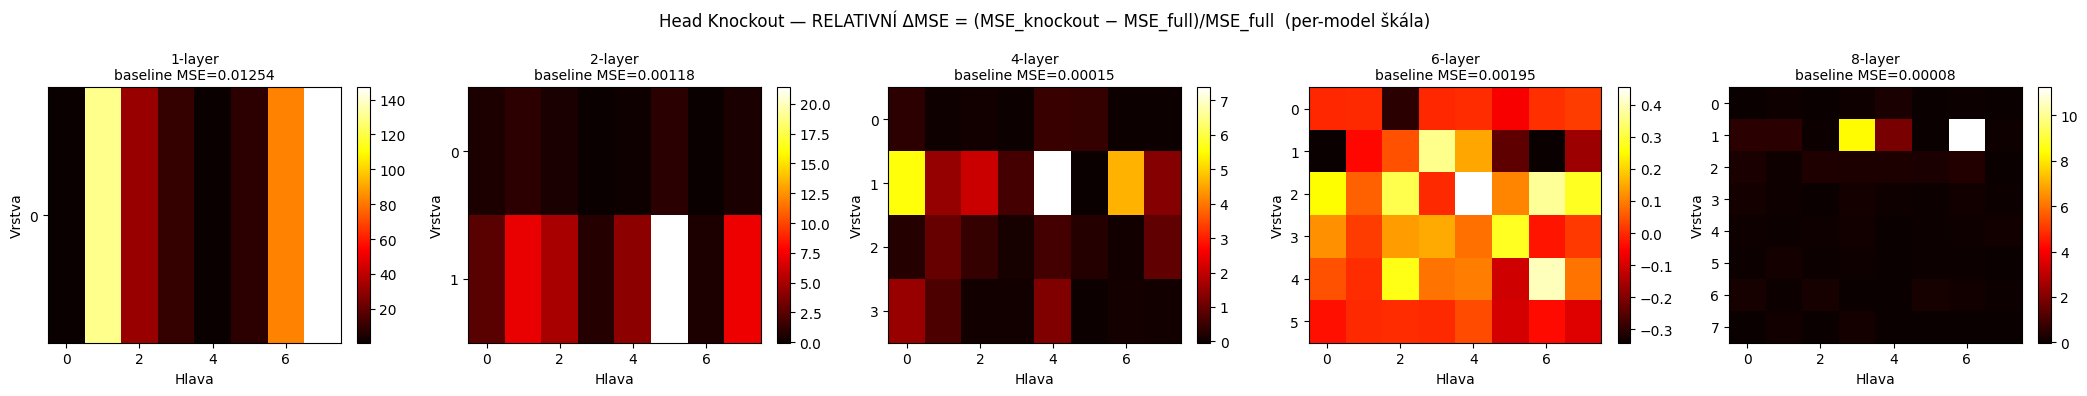


=== Head Knockout — relativní degradace (× baseline chyby) ===
Model       baseline MSE  max rel ΔMSE  nejdůl. (L,H)
------------------------------------------------------
1-layer         0.012543       147.0× (np.int64(0), np.int64(7))
2-layer         0.001182        21.4× (np.int64(1), np.int64(5))
4-layer         0.000152         7.4× (np.int64(1), np.int64(4))
6-layer         0.001954         0.5× (np.int64(2), np.int64(4))
8-layer         0.000077        11.2× (np.int64(1), np.int64(6))

Q3: EFEKTIVNÍ BANDWIDTH VS. LENGTHSCALE


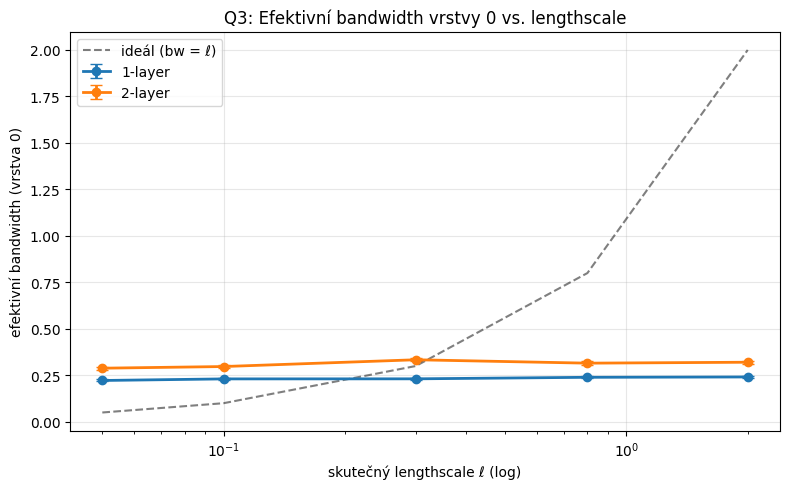


=== Q3: Průměrná bandwidth ±SE ===
     ℓ           1-layer           2-layer
------------------------------------------
  0.05    0.2222 ±0.0054    0.2883 ±0.0087
  0.10    0.2307 ±0.0059    0.2972 ±0.0081
  0.30    0.2311 ±0.0056    0.3336 ±0.0090
  0.80    0.2393 ±0.0063    0.3154 ±0.0095
  2.00    0.2411 ±0.0058    0.3203 ±0.0079


In [6]:
# =============================================================================
# SLOUČENÍ S EXPERIMENTEM 3: HEAD KNOCKOUT (kauzální) + Q3 BANDWIDTH
# =============================================================================
# Q1 z Exp 3 (label mixing vs kernel per vrstva) je DUPLIKÁT analýzy výše.
# Přenášíme jen kauzální metriku a bandwidth.
# Knockout: vynulujeme output-projekci hlavy (_w_out[h]=0), znovu spustíme PFN
#           a změříme ΔMSE = MSE(knockout, GP) − MSE(full, GP).
# =============================================================================
from scipy.stats import spearmanr


def _gp_post_mean(tx, ty, te, ls, noise, osc=1.0):
    d  = (tx[:, None] - tx[None, :]) ** 2
    K  = osc * np.exp(-d / (2 * ls ** 2)) + noise * np.eye(len(tx))
    ks = osc * np.exp(-((te[:, None] - tx[None, :]) ** 2) / (2 * ls ** 2))
    return ks @ np.linalg.solve(K, ty)


def _pfn_mean(model, tx, ty, te, device):
    with torch.no_grad():
        logits = model(tx[None].to(device), ty[None].to(device), te[None].to(device))
    return model.criterion.mean(logits)[0].cpu().numpy()


def run_head_knockout(model, datasets, n_context, hps, device, max_inst=50):
    """RELATIVNÍ degradace rel[layer, head] = (MSE(knockout, GP) − MSE(full, GP)) / MSE(full, GP).
    Absolutní ΔMSE je zavádějící — hluboké modely mají triviální baseline MSE, takže absolutní
    ΔMSE je z principu malé. Relativní metrika (× baseline chyby) ukazuje skutečnou důležitost.
    Vrací (rel, base_mse): rel = násobek baseline chyby, base_mse = průměrné MSE(full, GP)."""
    attn_mods = [m for n, m in model.named_modules()
                 if 'self_attn_between_items' in n and 'self_attn_between_items.' not in n]
    nL, nH = len(attn_mods), model.nhead
    sum_ko = np.zeros((nL, nH)); sum_base = np.zeros((nL, nH)); cnt = np.zeros((nL, nH))
    base_list = []
    for batch in datasets[:max_inst]:
        tx = batch.x[0, :n_context].to(device); ty = batch.y[0, :n_context].to(device)
        te = batch.x[0, n_context:].to(device)
        txn = tx.cpu().numpy().reshape(-1); tyn = ty.cpu().numpy().reshape(-1); ten = te.cpu().numpy().reshape(-1)
        try:
            gp = _gp_post_mean(txn, tyn, ten, hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0))
        except Exception:
            continue
        base = _pfn_mean(model, tx, ty, te, device)
        mse_full = float(np.mean((base - gp) ** 2))
        if not np.isfinite(mse_full) or mse_full < 1e-9:
            continue
        base_list.append(mse_full)
        for li, mod in enumerate(attn_mods):
            for h in range(nH):
                saved = mod._w_out.data[h].clone()
                mod._w_out.data[h].zero_()
                ko = _pfn_mean(model, tx, ty, te, device)
                mod._w_out.data[h].copy_(saved)
                mse_ko = float(np.mean((ko - gp) ** 2))
                if np.isfinite(mse_ko):
                    sum_ko[li, h] += mse_ko; sum_base[li, h] += mse_full; cnt[li, h] += 1
    rel = (sum_ko - sum_base) / np.maximum(sum_base, 1e-12)
    return rel, (float(np.mean(base_list)) if base_list else float("nan"))


def plot_knockout_all(results, base_mses):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
    if n == 1: axes = [axes]
    for ax, (name, rel) in zip(axes, results.items()):
        # PER-MODEL barevná škála (vlastní vmax) — jinak by hluboké modely byly černé
        im = ax.imshow(rel, aspect='auto', cmap='hot')
        ax.set_title(f'{name}\nbaseline MSE={base_mses[name]:.5f}', fontsize=10)
        ax.set_xlabel('Hlava'); ax.set_ylabel('Vrstva')
        ax.set_yticks(range(rel.shape[0]))
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle('Head Knockout — RELATIVNÍ ΔMSE = (MSE_knockout − MSE_full)/MSE_full  (per-model škála)', fontsize=12)
    plt.tight_layout(); plt.show()
    print("\n=== Head Knockout — relativní degradace (× baseline chyby) ===")
    print(f"{'Model':<10} {'baseline MSE':>13} {'max rel ΔMSE':>13} {'nejdůl. (L,H)':>14}")
    print("-" * 54)
    for name, rel in results.items():
        li, h = np.unravel_index(np.argmax(rel), rel.shape)
        print(f"{name:<10} {base_mses[name]:>13.6f} {rel[li, h]:>11.1f}× {str((li, h)):>14}")


def compute_effective_bandwidth(model, train_x, train_y, test_x, n_context, layer_idx=0):
    try:
        attn_all = extract_attention_weights(model, train_x, train_y, test_x, n_context)
    except Exception:
        return np.nan
    if layer_idx >= len(attn_all): return np.nan
    al = attn_all[layer_idx]; nh = al.shape[2]
    txn = train_x.cpu().numpy().reshape(-1); ten = test_x.cpu().numpy().reshape(-1)
    bw = []
    for ti in range(len(ten)):
        dist = np.abs(txn - ten[ti])
        bw.append(np.mean([float(np.dot(al[0, 0, h, n_context + ti, :n_context].detach().cpu().numpy(), dist))
                           for h in range(nh)]))
    return float(np.mean(bw))


def run_bandwidth_experiment(models_dict, lengthscales, n_instances, n_context, device, layer_idx=0):
    results = {name: {} for name in models_dict}
    for ell in lengthscales:
        hps_ell = {'noise': 1e-2, 'outputscale': 1.0, 'lengthscale': ell}
        for model_name, model in models_dict.items():
            bws = []
            for _ in range(n_instances):
                batch = get_batch_for_gp(batch_size=1, seq_len=n_context + 1, num_features=1,
                                         device='cpu', hyperparameters=hps_ell)
                tx = batch.x[0, :n_context].to(device); ty = batch.y[0, :n_context].to(device)
                te = batch.x[0, n_context:n_context + 1].to(device)
                bw = compute_effective_bandwidth(model, tx, ty, te, n_context, layer_idx)
                if not np.isnan(bw): bws.append(bw)
            m = np.mean(bws) if bws else np.nan
            s = np.std(bws) / np.sqrt(max(len(bws), 1)) if bws else np.nan
            results[model_name][ell] = (m, s)
    return results


def plot_bandwidth_vs_lengthscale(results, lengthscales):
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.tab10.colors
    for i, (name, d) in enumerate(results.items()):
        m = [d[e][0] for e in lengthscales]; s = [d[e][1] for e in lengthscales]
        ax.errorbar(lengthscales, m, yerr=s, marker='o', lw=2, capsize=4, color=colors[i], label=name)
    ax.plot(lengthscales, lengthscales, 'k--', alpha=0.5, label='ideál (bw = ℓ)')
    ax.set_xscale('log')
    ax.set_xlabel('skutečný lengthscale ℓ (log)'); ax.set_ylabel('efektivní bandwidth (vrstva 0)')
    ax.set_title('Q3: Efektivní bandwidth vrstvy 0 vs. lengthscale'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


# ── SPUŠTĚNÍ: head-knockout (všechny modely, sdílená data) ────────────────────
print("=" * 60); print("HEAD KNOCKOUT — kauzální metrika (ΔMSE vůči GP)"); print("=" * 60)
KNOCKOUT_INST = 50
knockout_results = {}; knockout_base = {}
for model_name, model in MODELS.items():
    print(f"  → {model_name} (knockout, {KNOCKOUT_INST} instancí)...")
    rel, base = run_head_knockout(model, shared_datasets, N_CONTEXT, hps, device, max_inst=KNOCKOUT_INST)
    knockout_results[model_name] = rel; knockout_base[model_name] = base
plot_knockout_all(knockout_results, knockout_base)

# ── SPUŠTĚNÍ: Q3 efektivní bandwidth (1-layer vs 2-layer) ─────────────────────
print("\n" + "=" * 60); print("Q3: EFEKTIVNÍ BANDWIDTH VS. LENGTHSCALE"); print("=" * 60)
Q3_MODELS = {k: v for k, v in MODELS.items() if k in ('1-layer', '2-layer')}
LENGTHSCALES = [0.05, 0.1, 0.3, 0.8, 2.0]
reset_seed()
q3_results = run_bandwidth_experiment(Q3_MODELS, LENGTHSCALES, 100, 20, device, layer_idx=0)
plot_bandwidth_vs_lengthscale(q3_results, LENGTHSCALES)
print("\n=== Q3: Průměrná bandwidth ±SE ===")
hdr = f'{"ℓ":>6}' + ''.join(f'  {n:>16}' for n in Q3_MODELS); print(hdr); print('-' * len(hdr))
for ell in LENGTHSCALES:
    row = f'{ell:>6.2f}'
    for name in Q3_MODELS:
        m, s = q3_results[name][ell]; row += f'  {m:>8.4f} ±{s:.4f}'
    print(row)


# Interpretace experimentu 1

Chtěli jsme se podívat, zda se ranní vrstvy chovají jako kernel-smoothing. Konkrétně, jestli se ranní vrstvy soustředí na vzdálenost mezi body a pozdější vrstvy na hodnoty jednotlivých bodů (label-like chování).

Předpokládali jsme, že se $\text{corr}(a_j^{(\ell)}, Y_j)$ bude snižovat s hloubkou vrstev a  $\text{corr}(a_j^{(\ell)}, k(x_*, X_j))$ zvyšovat.

První graf z experimentu znázorňuje celkový trend korelací skrz vrstvy jednotlivých modelů. Je vidět, že v ranních vrstvách model ještě přesně neví, čím se bude řídit, ale v dalších vrstvách je vidět, že PFN preferuje RBF chování, respektive kernel-smoothing chování, než se dívat na hodnoty $Y_j$.

## Co kód dělá — krok za krokem

### Kontext: proč tento experiment?

Každý transformer layer počítá attention score mezi testovacím bodem $x_*$ a každým trénovacím bodem $(X_j, Y_j)$. Tento score závisí na obou složkách:

$$a_j^{(\ell)} \propto \exp\!\bigl(x_*^\top W_Q^{(\ell)} \cdot [X_j, Y_j]^\top\bigr) = \exp(\alpha X_j + \beta Y_j)$$

Kdybychom měli $\beta = 0$, dostaneme Nadaraya-Watson odhad — attention závisí jen na vzdálenosti v prostoru příznaků (kernel-like). Pokud $\beta \neq 0$, attention závisí i na hodnotách labelů.

**Otázka:** Specializují se vrstvy? Používají rané vrstvy attention hlavně na $X_j$ (kernel) a pozdější na $Y_j$ (label propagation)?

---

### Jak experiment funguje

**1. Generování dat (`generate_datasets`)**

Jednou vygeneruje 200 náhodných GP vzorků se stejnými hyperparametry. Všechny modely dostanou přesně stejná data — to je klíčové pro férové srovnání. Každý vzorek má `n_context=40` trénovacích bodů a `n_test=20` testovacích bodů.

**2. Extrakce attention vah (`extract_attention_weights`)**

Protože PFNs `MultiHeadAttention` nevrací attention váhy přímo, používáme **forward hook**: zaregistrujeme funkci na vstup každého `self_attn_between_items` modulu, zachytíme aktivaci $x$, a pak ručně spočítáme $Q = xW_Q$, $K = xW_K$ a attention matici přes softmax.

Výsledek: pro každou vrstvu tensor tvaru `(1, 1, n_heads, seq_len, n_context)` — váhy každého bodu v sekvenci přes trénovací body.

**3. Výpočet metrik (`run_label_mixing_experiment`)**

Pro každý testovací bod $x_*$, každou vrstvu $\ell$ a každou hlavu $h$ spočítáme:

- **$\text{corr}(a_j^{(\ell,h)},\; k_\text{RBF}(x_*, X_j))$** — jak moc se attention podobá RBF kernel váhám (Nadaraya-Watson)
- **$|\text{corr}(a_j^{(\ell,h)},\; Y_j)|$** — jak moc attention závisí na hodnotách labelů

Obě hodnoty průměrujeme přes všechny testovací body a všechny vzorky (200×20 = 4000 měření na vrstvu a hlavu).

**4. MSE dekompozice (`run_mse_decomposition`)**

Pro různé počty kontextových bodů $n \in \{5, 10, 20, 40, 80, 120\}$ spočítáme MSE mezi PFN predikcí a přesným GP posteriorním průměrem. Fitujeme model $\text{MSE}(n) \approx \text{bias}^2 + c/n$. Pokud je $\text{bias}^2 > 0$ signifikantně, potvrzuje to Naglerův Theorem 5.4 — u jednovrstvého modelu bias nemůže vymizet.

**5. Iso-weight scatter (`plot_iso_weight_scatter`)**

Pro jeden konkrétní testovací bod $x_*$ vykreslíme trénovací body $(X_j, Y_j)$ obarvené dle attention váhy. Pokud jsou iso-váhové kontury **svislé pásy** (závisí jen na $X_j$) → kernel-like chování. Pokud jsou **diagonální** (závisí na $X_j + \alpha Y_j$) → label mixing.

**6. Srovnávací vizualizace (`plot_label_mixing_comparison`)**

Všechny modely na jednom grafu: $\text{corr}(\text{kernel})$ a $|\text{corr}(\text{label})|$ jako funkce čísla vrstvy. Šedý pás = std přes hlavy. Pokud u hlubšího modelu $\text{corr}(\text{kernel})$ roste s hloubkou → síť se specializuje.

# Interpretace

- Z experimentu máme hned několik zajímavých výsledků.
  
1) Viděli jsme, že jak pro jedno vrstevní model, tak i pro více vrstevní modely, nelze tvrdit, že dělají čistě kernel smoothing. V dřívějších experimentech jsme porovnávali attention z poslední vrstvy a RBF kernelem, ale tento experiment se nám nezdál korektně postaveny. Tady jsme vzali přímo jednotlivé vrstvy různých modelů a jejich hlavy. Dívali jsme se na korelaci attention vs. vzdálenost mezi body a na korelaci attention vs. hodnoty bodů, což jsme ukázali, že pro každou attention matici rozepsat jako: $$a_j^{(\ell)} \propto \exp\!\bigl(x_*^\top W_Q^{(\ell)} \cdot [X_j, Y_j]^\top\bigr) = \exp(\alpha X_j + \beta Y_j).$$
Z grafů je vidět, že PFN v každé vrstvě dělá obě věci najednou, pro kernel smoothing by platilo, že člen $\beta = 0$, ale PFN ani jeden z těchto koeficientů nemá nulové. Některé hlavy se dívají na $Y_j$ labely, jiné na okolí bodů a tento princip se zachovává skrz všechny vrstvy. Avšak pro všechny modely platí, že v ranních vrstvách se snaží více dělat něco podobného, jako kernel smoothing s tím, že navíc uvažuje i hodnoty bodů, ale v posledních vrstvách se děje něco úplně jiného, cože se nedá snadno interpretovat, protože tam se již pracuje s objekty, které prošly značnou transformaci v předchozích vrstvách. Dále jsme pro jednotlivé modely ukázali konkretní korelace skrz vrstvy a jejich výstup je konzistentní s diskuzí výše.
Původní hypotéza se potvrdila - PFN se v ranních vrstvách chová podobně jako kernel, ale navíc ještě využije informaci o hodnotě konkrétních bodů, avšak dále dělá něco sofistikovanějšího a jiného, než kernel funkce v GP. 

2) Jak se počítaly jednotlivé body v MSE dekompozici: Pro $\forall n \in {5, 10, 20, 40, 80, 120}$ kontext bodů se vzalo 200 předem generovaných datasetů. Pro každý dataset se spočítaly dvě predikce pro testovací body — jedna z PFN (forward pass → softmax → střední hodnota z BarDistribution) a jedna z analytického GP přesný výpočet přes Cholesky dekompozici $K^{-1}$. Fitujeme model $\text{MSE}(n) \approx \text{bias}^2 + c/n$, algoritmus najde hodnoty $\text{bias}^2$ a $c$, které minimalizují vzdálenost křivky od bodů.
 MSE mezi těmito dvěma predikcemi říká, jak daleko je PFN od správné odpovědi. Medián přes 200 instancí je ten bod v grafu, error bar je směrodatná chyba.
Graf MSE dekompozice potvrzuje teoretický závěr Naglera o biasu. Je vidět, že bias jedno vrstevního modelu je ohraničen zdola a nemůže klesnou pod určitou hodnotu. Pro Hlubší modely to už neplatí, bias klesá k nule. To ovšem platí pro za podmínek, že $K^{-1}$ je dobře podmíněná, pro špatnou podmíněnost úlohy bias nemusí klesat aní pro hlubší modely.

3) Iso grafy jsou posledním nástrojem, které ukazují, zda některé vrstvy dělají čistý kernel-smoothing či ne. Pokud by tak tomu bylo, attention u jednotlivých grafu měl vlnovitý tvar, jak tomu je na ukázce. Ale opět pozorujeme, že skutečně zatímco některé hlavy dělají něco podobného jako kernel-smoothing, jiné hlavy se zajímají o jiné věci. Výsledek je zcela konzistentní s diskuzí výše.